# Analisis y calibracion de instrumento MunRA
- Por Andre Jared Aguilar (UNAH)

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os, time, warnings, argparse
from scipy.optimize import curve_fit


import matplotlib.dates as mdates

columnas_cosmic_watch = [
    "EventNumber",            # Número secuencial del evento
    "Timestamp_ms",           # Tiempo desde inicio en milisegundos
    "ADC1_HighGain",          # Valor ADC canal alta ganancia
    "ADC2_LowGain",           # Valor ADC canal baja ganancia
    "SiPM_Peak_mV",           # Voltaje pico calibrado del SiPM (miliVoltios)
    "Pressure_Pa",            # Presión atmosférica en Pascales
    "Temperature_C",          # Temperatura en grados Celsius
    "DeadTime_us",            # Tiempo muerto en microsegundos
    "Coincident",             # Indicador de coincidencia (0=no, 1=sí)
    "DetectorName"            # Nombre o identificación del detector
]


## Datos de dispocision:

### Medicion desde caba;a
- Datos de 2905226_2100h con T=60
- datis de 3005226_1527h con T=60
- datis de 3005226_1654h con T=40
- datis de 3005226_1716h con T=20
- datis de 3005226_1750h con T=80
- munra_live_20260530_195547.txt T= 80 (Estos ha ya han sido con el nuevo escript)
- munra_live_20260530_204230.txt T=100

### Medicion anteriores (1 de enero)
Todos los datos estaba con T=80

## Forma de los textos

Aveces en los .text puede suceder que en partes de filas y columnas no esten completas, errores como que solo aparece un numero en una sola fila o texto aleatorio que suele suceder por errores el la lectura. Esto puede provocar que al leer nuestros datos nos de errores entre las filas y mas cuando se trabaja con `pandas`.

**Ejemplo:**


| ID   | Epoch   | Canal | Conteo | Energía | Tiempo   | Temp | Valor | Flag | Origen             |
|------|---------|-------|--------|---------|----------|------|-------|------|--------------------|
|AGHO  **ERROR → de escritura**         |       |        |         |          |      |       |       |                   |
| 1269 | 328737  | 90    | 1056   | 0.8     | 91082.6  | 28.9 | 5663  | 0    | MUNRA-LAGO-MAGHO   |
| 1270 | 328805  | 87    | 204    | 0.4     | 91082.6  | 28.9 | 5562  | 0    | MUNRA-LAGO-MAGHO   |
| 1271 | 329648  | 90    | 1501   | 0.9     | 91093.8  | 29.0 | 79410 | 0    | MUNRA-LAGO-MAGHO   |
| 1272 | 330624  | 109   | 2185   | 1.3     | 91095.7  | 29.0 | 79680 | 0    | MUNRA-LAGO-MAGHO   |
| 1273 | 330821  | 101   | 1962   | 1.2     | 91095.7  | 29.0 | 5820  | 0    | MUNRA-LAGO-MAGHO   |
| 1274 | 331438  | 100   | 1947   | 1.1     | 91098.4  | 29.0 | 42833 | 0    | MUNRA-LAGO-MAGHO   |
| 1275 | 332156  | 91    | 1544   | 0.9     | 91093.1  | 28.9 | 79688 | 0    | MUNRA-LAGO-MAGHO   |
| 1276 | 332166  | 92    | 192    | 0.4     | 91093.1  | 28.9 | 5847  | 0    | MUNRA-LAGO-MAGHO   |
| 0    | 334915  | 105   | 2008   | 1.2     | 91082.8  | 28.9 | 5615  | 0    | MUNRA-LAGO-MAGHO   |
| 1281 | **ERROR → fila incompleta, sin datos suficientes** |



In [2]:
def leer_archivo_cosmic(path):
    datos_limpios = []
    with open(path, "r", encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()
            if not linea:   # saltar líneas vacías
                continue

            partes = linea.split()

            # Validar que tenga al menos 10 columnas
            if len(partes) < 10:
                continue  # descartar filas incompletas

            datos_limpios.append(partes)
    return datos_limpios


In [3]:
data_01 = leer_archivo_cosmic('Datos_20260101.txt') #lee el archivo y pasa los que no tenga esos errores de escritura
df_01012026 = pd.read_csv(data_01,sep=r"\s+",on_bad_lines='skip',engine="python",names=columnas_cosmic_watch) #lo habre como dataframe
df_01012026

,EventNumber,Timestamp_ms,ADC1_HighGain,ADC2_LowGain,SiPM_Peak_mV,Pressure_Pa,Temperature_C,DeadTime_us,Coincident,DetectorName
0,1269,328737,90,1056,0.8,91082.6,28.9,5663,0,MUNRA-LAGO-MAGHO
1,1270,328805,87,204,0.4,91082.6,28.9,5562,0,MUNRA-LAGO-MAGHO
2,1271,329648,90,1501,0.9,91093.8,29.0,79410,0,MUNRA-LAGO-MAGHO
3,1272,330624,109,2185,1.3,91095.7,29.0,79680,0,MUNRA-LAGO-MAGHO
4,1273,330821,101,1962,1.2,91095.7,29.0,5820,0,MUNRA-LAGO-MAGHO
...,...,...,...,...,...,...,...,...,...,...
3529284,3530786,894751778,92,440,0.5,91107.7,30.6,5739,0,MUNRA-LAGO-MAGHO
3529285,3530787,894751798,92,1545,1.0,91107.7,30.6,5727,0,MUNRA-LAGO-MAGHO
3529286,3530788,894751901,105,2236,1.3,91107.7,30.6,5708,0,MUNRA-LAGO-MAGHO
3529287,3530789,894752099,93,1217,0.8,91107.7,30.6,44192,0,MUNRA-LAGO-MAGHO


In [4]:
df_01012026[df_01012026.iloc[:,0].values < 1269] #puede psara estos errores en los id

,EventNumber,Timestamp_ms,ADC1_HighGain,ADC2_LowGain,SiPM_Peak_mV,Pressure_Pa,Temperature_C,DeadTime_us,Coincident,DetectorName
8,0,334915,105,2008,1.2,91082.8,28.9,5615,0,MUNRA-LAGO-MAGHO


## NOTA proxima implementacion:
La nueva forma de los datos se viene previsto que el archivo python ``MUNRA_DATA`` sirva para demas de reducir los artefactos mencionado anteriormentes ademas de calcular el tiempo real en momento real. Por ahora, por cuestiones de calibracione de datos reales de la geotormenta, se usaran los datos que vienen directamente de ``minicom``.

Lo demas, se seguira el proceso que sigue el repositorio original del COSMIC WATCH v3 que es similar en cual se basa la construccion y toma de datos el MUNRA.
EL link del repositorio es:

https://github.com/spenceraxani/CosmicWatch-Desktop-Muon-Detector-v3X



## Tiempo de medicion y numero total de cuentas

In [5]:
PICO_timestamp_s = df_01012026['Timestamp_ms'].values / 1000.0 #tiempo de rasperri de ms a s

PICO_total_time_s = max(PICO_timestamp_s) - min(PICO_timestamp_s)
PICO_total_time_ms = PICO_total_time_s * 1000. # tiempo total en ms

#Variables de conteo y filtros lógicos
event_number = df_01012026['EventNumber'].values
total_counts = max(event_number.astype(int)) - min(event_number.astype(int))
#select_coincident = df_01012026['Coincident'].values.astype(bool) # Convierte 0 y 1 a False y True
print('Tiempo total:',PICO_total_time_ms)
print('NUmero total de conteo:',total_counts)

Tiempo total: 894423593.0
NUmero total de conteo: 3530790


In [26]:
(PICO_total_time_s/3600)/24 #duro 10 dias 

np.float64(10.352124918981481)

## Variables Fisicas

In [6]:
adc1_high = df_01012026['ADC1_HighGain'].values         
adc2_low = df_01012026['ADC2_LowGain'].values          
sipm = df_01012026['SiPM_Peak_mV'].values        

#Variables ambientales
temperature = df_01012026['Temperature_C'].values         
pressure = df_01012026['Pressure_Pa'].values         


### CORRECCIÓN DE TIEMPO MUERTO Y TIEMPO VIVO (FÍSICA DEL MUNRA)

Aca el tiempo muerto no uso ``np.diff`` porque el MUNRA ya me lo da

Aca lo importantes es `delta_pico_s`, tomo el primer tiempo  del arreglo de tiempos y le agrega a un nuevo arrgelo de la  misma forma y con `np.diff` realiza la diferencia.

Ejemplo: si ``PICO_timestamp_s = [10, 12, 15]``, entonces el resultado es ``[10, 10, 12, 15]`` de lo que hace ``np.append`` a al array original, luego la diferencia es: 
``np.diff([10, 10, 12, 15]) = [0, 2, 3]`` 

Esto es lo que calcula el $\Delta t$ de cuando tiempo paso entre particula entre un rayo anterior y el actual.

Y luego esta la parte del calculo del tiempo real ``PICO_event_livetime_s``

In [32]:
#aquí. Solo lo paso microsegundos a segundos.
event_deadtime_s = df_01012026['DeadTime_us'].values / 1000000.0
event_deadtime_ms = event_deadtime_s * 1000

# Al ser tiempo muerto individual, el tiempo muerto total de la campaña es la SUMA de todos ellos
total_deadtime_s = np.sum(event_deadtime_s)   #t=1,t_2=2 ... t_1+t_2+....    
total_deadtime_ms = total_deadtime_s * 1000. 
print('tiempo muerto total:',total_deadtime_ms)
        

# Calculamos el intervalo de tiempo real que pasó entre un evento y el anterior en la Pico
## El ejemplo de arriba
delta_pico_s = np.diff(np.append([PICO_timestamp_s[0]], PICO_timestamp_s))

# Tiempo Vivo = Tiempo transcurrido - Tiempo muerto de la electrónica
PICO_event_livetime_s = delta_pico_s - event_deadtime_s #osea cuanto tiempo estuvo "despierto" el detector listo para detectar otra particula! 

# esto evita micro-negativos numéricos por redondeo de la Pico
PICO_event_livetime_s = np.maximum(PICO_event_livetime_s, 0.0)
print('tiempo vivo promedio',np.mean(PICO_event_livetime_s))



tiempo muerto total: 90033781.99700004
tiempo vivo promedio 0.22793491375175462


In [28]:
total_deadtime_s/(3600) #un dia de tiempo muerto en totalidad

np.float64(25.009383888055567)

## Calculo de tiempo vivo global y la tasa de conteo
calculamos el Tiempo Vivo Global restando el tiempo total menos el tiempo muerto total
Seria:
$$t_{total,conteo} [s] = t_{RBpi,total} - t_{total,tiempo muerto} $$

Y para el rate [HZ] es:

$$ Rate (Hz)= \frac{\text{Eventos totales}}{∑ (\mtext{PICO_eventlivetime_s})}
 $$

y el error viene mediante la estadistica de Poisson (instrumentacion)

$$\sigma = \sqrt{N}$$

Pero este se divide el tiempo total del conteo en tiempo vivo>

In [8]:
live_time_s = PICO_total_time_s - total_deadtime_s
live_time_ms = PICO_total_time_ms - total_deadtime_ms #en ms mejor

count_rate = total_counts / live_time_s #numero de particulas
count_rate_err = np.sqrt(total_counts) / live_time_s #error estadistico
print("Total Count Rate: ", np.round(count_rate, 4), "+/-", np.round(count_rate_err, 4), "Hz")

Total Count Rate:  4.3894 +/- 0.0023 Hz


## Reducción Temporal de Datos (Binning).
Lo fundamental es pasar de la física de "partícula por partícula" (es decir de numero de particulas de toda la fila) a una serie temporal discreta (puntos fijos en el tiempo: minuto a minuto, hora a hora).

La formula total es:
$$\text{Tasa (Hz)} = \frac{\text{Conteos en el minuto } i}{\text{Tiempo Vivo neto en el minuto } i}$$

Esta es la tasa total corregida. LO anterior es **una tasa temporal promedio**, con este proceso se obtendra el flujo ordenado **cronologicamente**.

Ocupamos dividir nuestros datos en bloques entre el minimo de datos y el maximo, del cual viene dado por el ``bin_size`` que servira para reconocer cuantas particulas cayeron en esa ventana de tantos segundos.

Para esto no es un simple conteo o numero, debe ser un **histograma** por el proceso de binearizacion con su correspondiente error de este proceso. 

Ejemplo del proceso. 
- si mi bin es de $60 seg$ (una ventana de cuantas particulas caen en 60 segundos), entonces entre el ``n`` total de datos dividir en cuantas ventanas se ocupa para hacer la tasa.

Lo que se obtendra es:

En el minuto 1 cayeron 90 partículas, en el minuto 2 cayeron 85, en el minuto 3 cayeron 92..."

In [9]:
#primero hay que saber en cuanto vamos a caracterizar la tasa de particulas
bin_size = 60 #de 60 segundos sera la tasa
bins = range(int(min(PICO_timestamp_s)), int(max(PICO_timestamp_s)), bin_size) 

# Histograma de conteos globales y cálculo de Tiempo Vivo Neto por bloque
counts, binEdges = np.histogram(PICO_timestamp_s, bins=bins) #creacion del histograma total
bin_livetime, _ = np.histogram(PICO_timestamp_s, bins=bins, weights=PICO_event_livetime_s) #la parte fundamental
bin_livetime = np.maximum(bin_livetime, 0.001)  # Escudo contra división por cero

El histograma ``bin_livetime`` es importante ya que no solo es contar cuantos eventos hubo en un tiempo, sino que en esa ventana ver el tiempo real que el detector estaba en funcionamiento en ese bloque de tiempo para ver una particula (es decir, ignorando el tiempo que el detector estuvo leyendo una particula o registrandola).

En conclusion nos da el **tiempo vivo instantáneo de esa partícula** en ese bloque correspondiente.

Idea de lo que hace:
- Si en el minuto 2 hubo mucho ruido electrónico y el detector estuvo ciego un rato, bin_livetime para ese minuto no será 60.0s, sino tal vez 57.4s.


In [10]:
binned_counts = counts
binned_counts_err = np.sqrt(counts) # la incertidumbre
binned_count_rate = counts / bin_livetime #conteo total entre el tiempo de conteo
binned_count_rate_err = np.sqrt(counts) / bin_livetime # el error del conteo


In [11]:
## BINEO para el tiempo muerto
bin_deadtime, _ = np.histogram(PICO_timestamp_s, bins=bins, weights=event_deadtime_s)
binned_deadtime_percentage = (bin_deadtime / bin_size) * 100

El ``binned_deadtime_percentage`` es una serie temporal que dice el porcentaje de cada minuto pasó el detector "bloqueado" procesando señales. Es una métrica excelente para monitorear la salud de la electrónica de la estación.

Algo muy importante es y son los pesos, es una matriz (vector) que ayuda a que cada particula se le asigna un valor de importancia estadistico, esto para hacer que el total de particulas en el tiempo trancurrido, y nos menciona o describe es que de los n elementos (que son los eventos) valga exactamente lo mismo, como una normalizacion.

Es util en el grafico visual en ves de un simple conteo, se vuelve un conteo de espectro real, lo que sirve como normalizacion

In [12]:
weights = np.ones(len(event_number)) / live_time_s

#### Nota: Estos pesos se usa hasta la grafica de n_plots solo cuando el propsito es comparar 2 hisrogramas diferentes (lo que se hara despues en grafico de N_plot), no los anterior ya que la fisica de conteo de particulas  busco acumular (sumar) duraciones reales de tiempo vivo

## Nota
Si tivieramos el otro MUNRA conectado a otro para las coincidencias.

SI se hace el bineo para el rate del conteo, es necesario realizar el proceso anterior para las variables atmosfericas, es decir que el script necesita saber qué presión y qué temperatura promedió el laboratorio en cada intervalo temporal.

Ver en la ventana que se hizo para la tasa, cuatas mediciones de presion se realizo, igual para la temperatura, y este se divide por el numero maixmo del valor de la variable , lo que nos da el promedio exacto en ese bin, y el 1 es por si en ese tiempo no cayo una particula, evita que la variable sea 0 y la hace 1.

In [13]:
sum_pressure, _ = np.histogram(PICO_timestamp_s, bins=bins, weights=pressure)
count_pressure, _ = np.histogram(PICO_timestamp_s, bins=bins)
binned_pressure = sum_pressure / np.maximum(count_pressure, 1)

sum_temperature, _ = np.histogram(PICO_timestamp_s, bins=bins, weights=temperature)
count_temperature, _ = np.histogram(PICO_timestamp_s, bins=bins)
binned_temperature = sum_temperature / np.maximum(count_temperature, 1)

In [14]:
## Esto es necesario si hay un ajuste, los bins al ser "caja" de tama;o x, el punto exacto es en una esquina, lo util es que sea en el centro
bincenters = 0.5 * (binEdges[1:] + binEdges[:-1])
binned_time_s = bincenters
binned_time_m = bincenters / 60.0  # Tiempo en minutos
binned_time_h = bincenters / 3600.0 # Tiempo en horas

### Dataframe total

In [15]:
df_01012026_binned = pd.DataFrame({
    'Time_s': binned_time_s,
    'Time_min': binned_time_m,
    'Time_hours': binned_time_h,
    'Counts_All': binned_counts,
    'Rate_All_Hz': binned_count_rate,
    'Rate_All_Err_Hz': binned_count_rate_err,
    'DeadTime_Pct': binned_deadtime_percentage,
    'Pressure_Pa': binned_pressure,
    'Temperature_C': binned_temperature
})

SI hubiera coincidencias

## Resultado

In [16]:
df_01012026_binned

,Time_s,Time_min,Time_hours,Counts_All,Rate_All_Hz,Rate_All_Err_Hz,DeadTime_Pct,Pressure_Pa,Temperature_C
0,358.0,5.966667,0.099444,9,1.532294,0.510765,0.516863,91090.866667,28.944444
1,418.0,6.966667,0.116111,0,0.000000,0.000000,0.000000,0.000000,0.000000
2,478.0,7.966667,0.132778,0,0.000000,0.000000,0.000000,0.000000,0.000000
3,538.0,8.966667,0.149444,0,0.000000,0.000000,0.000000,0.000000,0.000000
4,598.0,9.966667,0.166111,0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
14902,894478.0,14907.966667,248.466111,214,3.950147,0.270026,9.806325,91093.865420,30.700000
14903,894538.0,14908.966667,248.482778,229,4.277741,0.282681,9.968460,91098.775546,30.667686
14904,894598.0,14909.966667,248.499444,229,4.231358,0.279616,10.072093,91106.001747,30.651528
14905,894658.0,14910.966667,248.516111,235,4.329872,0.282450,10.093838,91103.588511,30.618723


In [42]:
df_01012026_binned['Rate_All_Hz'].corr(df_01012026_binned['Pressure_Pa'])

np.float64(0.04483897479278189)

## Analisis Dataframe
- ``Time_s`` , ``Time_min `` y  ``Time_hours``: Es el punto central de cada ventana temporal medido en segundos, minutos y horas desde que arrancó la medicion. Con total en la ultima fila de 248.53 hr.

- ``Counts_All``: Es la cantidad exacta de partículas (conteos puros) que impactaron el plástico centellador dentro de ese minuto específico.

- ``Rate_All_Hz``: Es la Tasa de Conteo Real Corregida expresada en Hercios (pulsos por segundo). Se calcula dividiendo Counts_All entre el tiempo vivo neto de ese minuto. y ``Rate_All_Err_Hz``: Es la incertidumbre o barra de error estadística de la tasa para ese minuto, calculada mediante la estadística de Poisson.

- ``DeadTime_Pct``: Es el porcentaje de ese minuto en el que el detector estuvo "ciego" procesando datos.


### nota:
Al inicio vemos que hay filas con 0.00, puedes ser un error que puede ser provocado por el del detector internamente o de la binearizacion

In [17]:
#una forma de saber cuanfo falla es que las variables de presion y temperatura sean 0 o que se desvian mucho respecto al total.
# Esto porque estos detectores estan en paralelo dentro de la intrumentacion
cond_data = (df_01012026_binned['Pressure_Pa'] == 0) & (df_01012026_binned['Temperature_C'] == 0) 
df_01012026_binned = df_01012026_binned[~cond_data] #seleciona los que no cumplan la anterior condicion
df_01012026_binned

,Time_s,Time_min,Time_hours,Counts_All,Rate_All_Hz,Rate_All_Err_Hz,DeadTime_Pct,Pressure_Pa,Temperature_C
0,358.0,5.966667,0.099444,9,1.532294,0.510765,0.516863,91090.866667,28.944444
5,658.0,10.966667,0.182778,171,0.492554,0.037667,8.425213,91080.812281,29.159064
6,718.0,11.966667,0.199444,233,4.248089,0.278302,9.738003,91077.198712,29.190129
7,778.0,12.966667,0.216111,237,4.370854,0.283917,9.706980,91078.794937,29.188186
8,838.0,13.966667,0.232778,204,3.768692,0.263861,9.461352,91079.514216,29.154412
...,...,...,...,...,...,...,...,...,...
14902,894478.0,14907.966667,248.466111,214,3.950147,0.270026,9.806325,91093.865420,30.700000
14903,894538.0,14908.966667,248.482778,229,4.277741,0.282681,9.968460,91098.775546,30.667686
14904,894598.0,14909.966667,248.499444,229,4.231358,0.279616,10.072093,91106.001747,30.651528
14905,894658.0,14910.966667,248.516111,235,4.329872,0.282450,10.093838,91103.588511,30.618723


## Analisis de resultados

In [18]:
print("=============================================================")
print("   REPORTE DE RESULTADOS: ESTACIÓN MuNRA (01/01/2026)        ")
print("=============================================================\n")

duracion_total_h = df_01012026_binned['Time_hours'].max()
total_bins = len(df_01012026_binned)
print(f"Duración total del archivo analizado: {duracion_total_h:.2f} horas")
print(f"Número total de bloques temporales (bins): {total_bins}")
print(f"Tamaño de cada ventana temporal (bin_size): {bin_size} segundos\n")

print("-------------------------------------------------------------")
print("RESULTADOS FÍSICOS (TASAS DE CONTEO)")
print("-------------------------------------------------------------")
tasa_media = df_01012026_binned['Rate_All_Hz'].mean()
tasa_std = df_01012026_binned['Rate_All_Hz'].std()
max_tasa = df_01012026_binned['Rate_All_Hz'].max()
min_tasa = df_01012026_binned['Rate_All_Hz'].min()

print(f"🔹 Tasa de Conteo Promedio: {tasa_media:.4f} Hz (pulsos/segundo)")
print(f"🔹 Desviación Estándar Temporal (σ): {tasa_std:.4f} Hz")
print(f"🔹 Fluctuación Máxima Registrada: {max_tasa:.4f} Hz")
print(f"🔹 Fluctuación Mínima Registrada: {min_tasa:.4f} Hz\n")

print("-------------------------------------------------------------")
print("DIAGNÓSTICO DE SALUD INSTRUMENTAL")
print("-------------------------------------------------------------")
deadtime_medio = df_01012026_binned['DeadTime_Pct'].mean()
deadtime_max = df_01012026_binned['DeadTime_Pct'].max()
print(f"Porcentaje de Tiempo Muerto Promedio: {deadtime_medio:.2f}%")
print(f"Pico Máximo de Saturación Electrónica: {deadtime_max:.2f}%\n")

print("-------------------------------------------------------------")
print("MONITOREO ATMOSFÉRICO LOCAL")
print("-------------------------------------------------------------")
presion_media_kPa = df_01012026_binned['Pressure_Pa'].mean() / 1000.0
presion_delta_kPa = (df_01012026_binned['Pressure_Pa'].max() - df_01012026_binned['Pressure_Pa'].min())/1000
temp_media = df_01012026_binned['Temperature_C'].mean()

print(f"Presión Barométrica Media: {presion_media_kPa:.2f} kPa")
print(f"Variación de Presión durante el día (ΔP): {presion_delta_kPa:.1f} kPa")
print(f"Temperatura Promedio en el Módulo: {temp_media:.2f} °C")
print("=============================================================")

   REPORTE DE RESULTADOS: ESTACIÓN MuNRA (01/01/2026)        

Duración total del archivo analizado: 248.53 horas
Número total de bloques temporales (bins): 14903
Tamaño de cada ventana temporal (bin_size): 60 segundos

-------------------------------------------------------------
RESULTADOS FÍSICOS (TASAS DE CONTEO)
-------------------------------------------------------------
🔹 Tasa de Conteo Promedio: 4.3890 Hz (pulsos/segundo)
🔹 Desviación Estándar Temporal (σ): 0.2946 Hz
🔹 Fluctuación Máxima Registrada: 5.4712 Hz
🔹 Fluctuación Mínima Registrada: 0.4926 Hz

-------------------------------------------------------------
DIAGNÓSTICO DE SALUD INSTRUMENTAL
-------------------------------------------------------------
Porcentaje de Tiempo Muerto Promedio: 10.07%
Pico Máximo de Saturación Electrónica: 10.69%

-------------------------------------------------------------
MONITOREO ATMOSFÉRICO LOCAL
-------------------------------------------------------------
Presión Barométrica Media: 90.

La variacion de la presion es grande ya que hay datos que no hubo detccion de particulas , eos hace que sea la variacion de 90, ya que 0+90/2 hace que se vea ese error. Se puede corregir en ves de ``min`` y ``max`` por otra cosa

# Grafico de Rate-PLot
``RatePlotBandaMuNRA``, representa una evolución metodológica muy importante respecto al script original de CosmicWatch. Está diseñada específicamente bajo los estándares física de altas energías para el análisis de series temporales de alta densidad.
El script original utilizaba ``plt.errorbar``, que dibuja un punto y una cruz vertical por cada minuto de datos. Al transformar el gráfico a una Banda de Error Continua (Shaded Error Band), se cambia el enfoque visual.

- La línea central oscura representa el valor esperado o promedio de la tasa de partículas en cada bloque de tiempo.
- La banda clara transparente representa el espacio geométrico de la incertidumbre estadística ($\pm\sigma$).

Para la visualización y el análisis de las series temporales de alta densidad de flujo, se desarrolló un algoritmo de suavizado geométrico basado en bandas de error continuas en estilo escalón (step-binned). En lugar de utilizar barras de error discretas que saturan el lienzo visual ante grandes volúmenes de datos, el software computa de forma vectorial el intervalo de confianza de Poisson ($\pm\sigma$) para cada intervalo de integración temporal, generando una región continua de incertidumbre mediante interpolación de bordes ortogonales (step='post'). Esto permite aislar visualmente las variaciones de baja frecuencia del clima espacial, manteniendo el rigor metrológico de la estadística de conteo

In [50]:
class RatePlotMuNRA():
    def __init__(self,
                 time,
                 rate,
                 rate_err,
                 color_dark='#002244',   # Color oscuro y elegante para la línea central
                 color_light='#6699CC',  # Color claro/pastel para la banda de error
                 alpha_band=0.25,        # Transparencia ideal para el sombreado
                 xmin=None, xmax=None, ymin=None, ymax=None,
                 figsize=[9, 5], fontsize=14,
                 xlabel='', ylabel='', label='Tasa de Conteo',
                 pdf_name='', title=''):
        
        fig, ax = plt.subplots(figsize=figsize)
        
        ax.set_axisbelow(True)
        ax.grid(which='both', linestyle='--', alpha=0.35, zorder=0)
        
        #Calcular los límites matemáticos de la banda de error (Techo y Piso)
        piso_error = np.array(rate) - np.array(rate_err)
        techo_error = np.array(rate) + np.array(rate_err)
        
        #DIBUJAR LA BANDA DE ERROR
        # El parámetro step='post' fuerza a que el sombreado siga el estilo escalón
        ax.fill_between(time, piso_error, techo_error, 
                        step='post', 
                        color=color_light, 
                        alpha=alpha_band, 
                        zorder=2, 
                        label=r'Incertidumbre ($\pm\sigma$)')
        
        # DIBUJAR EL VALOR CENTRAL (Línea sólida y oscura)
        # El parámetro where='post' alinea la línea perfectamente con el sombreado
        ax.step(time, rate, 
                where='post', 
                color=color_dark, 
                linewidth=2.0, 
                zorder=3, 
                label=label)
        
        # Configuración y autoajuste inteligente de los ejes
        if xmin is None: xmin = np.nanmin(time)
        if xmax is None: xmax = np.nanmax(time)
        if ymin is None: ymin = np.nanmin(piso_error) * 0.95
        if ymax is None: ymax = np.nanmax(techo_error) * 1.05
            
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        
        ax.set_ylabel(ylabel, size=fontsize)
        ax.set_xlabel(xlabel, size=fontsize)
        ax.tick_params(axis='both', which='both', labelsize=fontsize-2)
        ax.set_title(title, fontsize=fontsize+2, fontweight='bold')
        
        ax.legend(fontsize=fontsize-3, loc='upper right', fancybox=True, frameon=True)
        
        plt.tight_layout()
        if pdf_name != '':
            print(f'Guardando gráfico estético en: {pdf_name}')
            plt.savefig(pdf_name, format='pdf', transparent=True, bbox_inches='tight')
            
        plt.show()

Guardando gráfico estético en: MuNRA_TimeSeries_hour.pdf


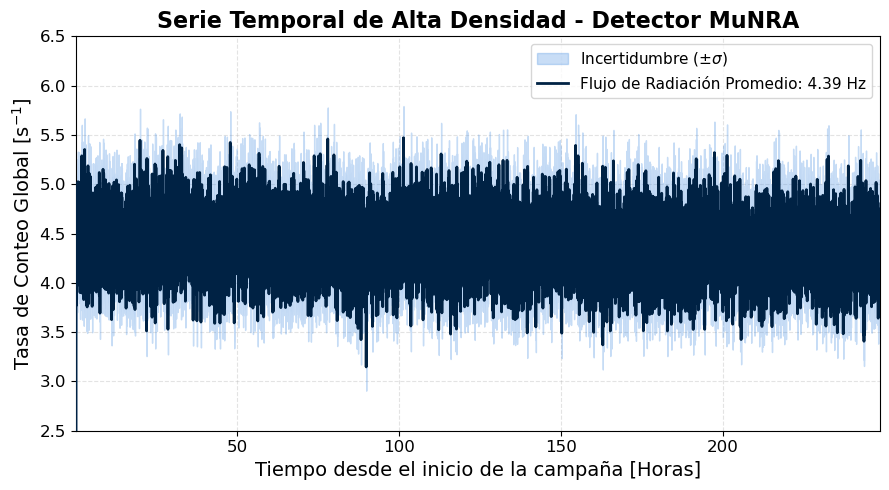

In [55]:
# Filtro rápido de seguridad para remover el cero artificial del inicio
df_grafico = df_01012026_binned[df_01012026_binned['Rate_All_Hz'] > 0.5].copy()

grafico_temporal = RatePlotMuNRA(
    time=df_grafico['Time_hours'],
    rate=df_grafico['Rate_All_Hz'],
    rate_err=df_grafico['Rate_All_Err_Hz'],
    
    # Paleta de colores Premium (Azul marino profundo para el centro, azul cielo para el error)
    color_dark='#002244', 
    color_light='#4A90E2', 
    alpha_band=0.30, 
    
    ymin=2.5, ymax=6.5, 
    
    xlabel='Tiempo desde el inicio de la campaña [Horas]',
    ylabel=r'Tasa de Conteo Global [s$^{-1}$]',
    label=f'Flujo de Radiación Promedio: {df_grafico["Rate_All_Hz"].mean():.2f} Hz',
    title='Serie Temporal de Alta Densidad - Detector MuNRA',
    pdf_name='MuNRA_TimeSeries_hour.pdf'
)

Lo importante de esta funcion es que adaptable, ya que solo toma arrays de nuestros datos y no todo, por ende se puede usar dependiendo de que serie temporal queremos usar.

Si queremos ver las fechas exactas, podemos usar las funciones de ``datetime`` para dar el tiempo exacto

In [56]:
#teniamos esta df ya filtrado:
df_grafico

,Time_s,Time_min,Time_hours,Counts_All,Rate_All_Hz,Rate_All_Err_Hz,DeadTime_Pct,Pressure_Pa,Temperature_C
0,358.0,5.966667,0.099444,9,1.532294,0.510765,0.516863,91090.866667,28.944444
6,718.0,11.966667,0.199444,233,4.248089,0.278302,9.738003,91077.198712,29.190129
7,778.0,12.966667,0.216111,237,4.370854,0.283917,9.706980,91078.794937,29.188186
8,838.0,13.966667,0.232778,204,3.768692,0.263861,9.461352,91079.514216,29.154412
9,898.0,14.966667,0.249444,254,4.687483,0.294119,9.888565,91079.056693,29.123228
...,...,...,...,...,...,...,...,...,...
14902,894478.0,14907.966667,248.466111,214,3.950147,0.270026,9.806325,91093.865420,30.700000
14903,894538.0,14908.966667,248.482778,229,4.277741,0.282681,9.968460,91098.775546,30.667686
14904,894598.0,14909.966667,248.499444,229,4.231358,0.279616,10.072093,91106.001747,30.651528
14905,894658.0,14910.966667,248.516111,235,4.329872,0.282450,10.093838,91103.588511,30.618723


## Rolling median

El rolling media es como un tipo de filtro de medianas pero este no toca los datos o los modifica, es como la binearizacion pero para un uso de visualizacion.

Lo que hace es que se usa una ventana de cualquiero valor y este hace un promedio de los valores de esos puntos. Por ejemplo si se elige la variables de ``time_hours`` lo que hara es que definieremos una ventana de minutos, en este caso de 60 min, eso sinifica que en un intervalo de tiempo calculara la mediana (o media) entre ese intervalo de datos y los remplazara, esto hace que se reduscan los datos que se graficaran en un futuro lo que hace que se disminuya la densidad de puntos en a grafica y nos de una mejor didentificaciones de patrones.

In [64]:
fecha_inicio = pd.to_datetime('2026-01-01 07:00:00') #fecha y hora exacta de inicio de la campaña (1 de Enero de 2026, 07:00 AM)34

df_abs = df_01012026_binned[df_01012026_binned['Rate_All_Hz'] > 0.5].copy() #filtro anterior

# Construir el eje de tiempo absoluto sumando las horas relativas a la fecha base
df_abs['Datetime'] = fecha_inicio + pd.to_timedelta(df_abs['Time_hours'], unit='h')

## Aplicando la rolling media para una mejor visualizacion
#(Opcional)

ventana_minutos = 60

# Calcular la Media Móvil (Rolling Mean) sobre el valor central
df_abs['Rate_Smooth'] = df_abs['Rate_All_Hz'].rolling(window=ventana_minutos, center=True).mean() 

#Propagación rigurosa del error estadístico para la banda de confianza
df_abs['Rate_Err_Smooth'] = df_abs['Rate_All_Err_Hz'].rolling(window=ventana_minutos, center=True).apply(
    lambda x: np.sqrt(np.sum(x**2)) / len(x), raw=True
)

# Eliminar las filas de los extremos que quedan vacías debido a la ventana del filtro
df_abs = df_abs.dropna(subset=['Rate_Smooth'])

Para graficar usando Datetime, lo que se hace es usar la misma funcion aanterior pero adaptada a este nuevo formato porque sino, sera un error. Aca use la IA para ahorrar el tiempo

In [72]:
class RatePlotBandaMuNRA():
    def __init__(self,
                 time,
                 rate,
                 rate_err,
                 color_dark='#002244',   # Línea de tendencia (Oscura)
                 color_light='#4A90E2',  # Banda de error (Clara)
                 alpha_band=0.25,
                 xmin=None, xmax=None,   # <-- ¡Aceptan strings de fecha o objetos datetime!
                 ymin=None, ymax=None,   # Autoajuste si se dejan en None
                 figsize=[11, 5], fontsize=14,
                 xlabel='Fecha de Medición (Año 2026)', ylabel=r'Tasa de Conteo Suavizada [s$^{-1}$]',
                 label='Flujo Suavizado',
                 pdf_name='', title=''):
        
        # 1. Forzar conversión a formatos vectoriales de NumPy/Pandas
        time_series = pd.to_datetime(time).reset_index(drop=True)
        rate_series = np.array(rate)
        rate_err_series = np.array(rate_err)
        
        # 2. --- FILTRO DE INTERVALO DE EVALUACIÓN AUTOMÁTICO (Slicing) ---
        if xmin is not None:
            xmin = pd.to_datetime(xmin)
            mask = time_series >= xmin
            time_series = time_series[mask].reset_index(drop=True)
            rate_series = rate_series[mask]
            rate_err_series = rate_err_series[mask]
            
        if xmax is not None:
            xmax = pd.to_datetime(xmax)
            mask = time_series <= xmax
            time_series = time_series[mask].reset_index(drop=True)
            rate_series = rate_series[mask]
            rate_err_series = rate_err_series[mask]
            
        # Calcular los techos y pisos estadísticos del segmento recortado
        piso = rate_series - rate_err_series
        techo = rate_series + rate_err_series
        
        # 3. Inicializar el lienzo gráfico
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_axisbelow(True)
        ax.grid(which='both', linestyle='--', alpha=0.35, zorder=0)
        
        # 4. Dibujar la física (Banda + Línea central en escalón)
        ax.fill_between(time_series, piso, techo, step='post', 
                        color=color_light, alpha=alpha_band, zorder=2, label=r'Incertidumbre ($\pm\sigma$)')
        ax.step(time_series, rate_series, where='post', 
                color=color_dark, linewidth=1.6, zorder=3, label=label)
        
        # 5. --- FORMATEO EXCLUSIVO DEL EJE X (Horas, Día y Mes) ---
        # Calculamos la duración del intervalo seleccionado para elegir la mejor escala visual
        duracion = time_series.max() - time_series.min()
        
        if duracion.days <= 2:
            # Si el intervalo es de 2 días o menos, ponemos marcas cada 3 horas (Zoom de eventos)
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%H:%M')) # Ej: 03-Jan \n 12:00
            ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
        elif duracion.days <= 5:
            # Intervalos medianos: marcas cada 12 horas
            ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%H:%M'))
            ax.xaxis.set_minor_locator(mdates.HourLocator(interval=3))
        else:
            # Campaña completa (más de 5 días): marcas cada 24 horas (A la medianoche)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%H:%M'))
            ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18])) # Guías cada 6 horas
            
        fig.autofmt_xdate() # Rotación automática inclinada para que las horas no se traslapen
        
        # 6. Configuración de límites y márgenes inteligentes
        ax.set_xlim(time_series.min(), time_series.max())
        
        if ymin is None: ymin = np.nanmin(piso) * 0.99
        if ymax is None: ymax = np.nanmax(techo) * 1.01
        ax.set_ylim(ymin, ymax)
        
        # Textos de formato
        ax.set_ylabel(ylabel, size=fontsize)
        ax.set_xlabel(xlabel, size=fontsize)
        ax.tick_params(axis='both', which='both', labelsize=fontsize-2)
        ax.set_title(title, fontsize=fontsize+2, fontweight='bold')
        ax.legend(loc='upper right', fancybox=True, frameon=True)
        
        plt.tight_layout()
        if pdf_name != '':
            print(f'Guardando PDF evaluado en: {pdf_name}')
            fig.savefig(pdf_name, format='pdf', transparent=True, bbox_inches='tight')
        plt.show()

In [69]:
df_abs 

,Time_s,Time_min,Time_hours,Counts_All,Rate_All_Hz,Rate_All_Err_Hz,DeadTime_Pct,Pressure_Pa,Temperature_C,Datetime,Rate_Smooth,Rate_Err_Smooth
35,2458.0,40.966667,0.682778,266,4.950994,0.303565,10.197473,91040.317669,29.087218,2026-01-01 07:40:58.000000000,4.436885,0.037833
36,2518.0,41.966667,0.699444,238,4.403295,0.285423,9.880938,91041.364286,29.074370,2026-01-01 07:41:57.999999998,4.489109,0.037189
37,2578.0,42.966667,0.716111,246,4.581059,0.292078,9.772705,91041.821138,29.056504,2026-01-01 07:42:57.999999999,4.492994,0.037205
38,2638.0,43.966667,0.732778,241,4.402459,0.283587,9.908112,91044.395436,29.059751,2026-01-01 07:43:58.000000000,4.497554,0.037225
39,2698.0,44.966667,0.749444,246,4.644925,0.296150,9.799505,91043.081301,29.021138,2026-01-01 07:44:57.999999998,4.507098,0.037265
...,...,...,...,...,...,...,...,...,...,...,...,...
14873,892738.0,14878.966667,247.982778,231,4.279398,0.281564,9.984080,91051.783117,30.780087,2026-01-11 14:58:58.000000000,4.277960,0.036342
14874,892798.0,14879.966667,247.999444,240,4.499629,0.290450,10.105448,91050.351667,30.767500,2026-01-11 14:59:57.999999998,4.284368,0.036373
14875,892858.0,14880.966667,248.016111,258,4.752536,0.295880,10.275325,91051.793411,30.754264,2026-01-11 15:00:57.999999999,4.282491,0.036365
14876,892918.0,14881.966667,248.032778,220,4.056849,0.273513,9.856195,91056.395909,30.719091,2026-01-11 15:01:58.000000000,4.282814,0.036365


Guardando PDF evaluado en: MuNRA_Campaña_Completa_2026.pdf


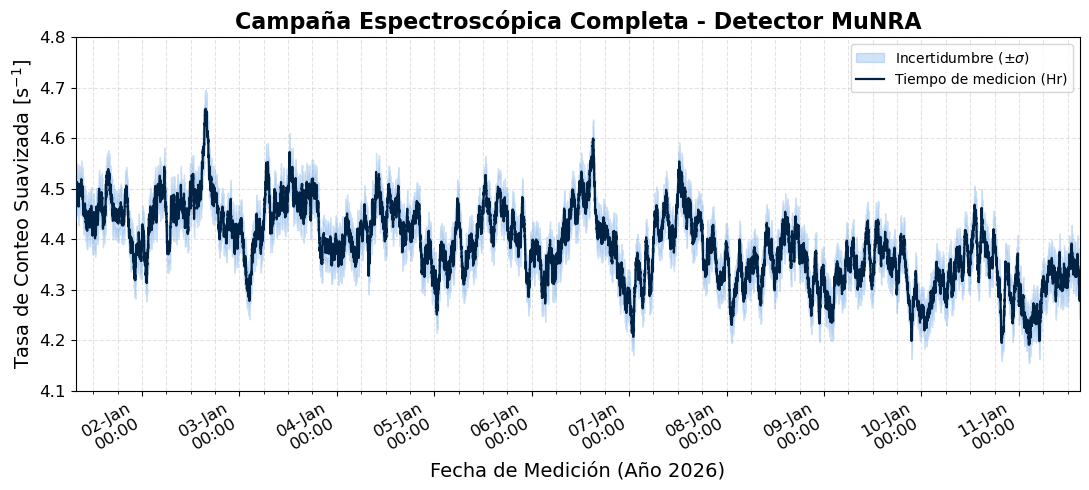

In [71]:
grafico_completo = RatePlotBandaMuNRA(
    time=df_abs['Datetime'],
    rate=df_abs['Rate_Smooth'],
    rate_err=df_abs['Rate_Err_Smooth'],
    xmin=None, xmax=None, # Muestra todo el mes mapeado
    ymin=4.1, ymax=4.8,   # Zoom optimizado para ver las ondas diurnas
    label='Tiempo de medicion (Hr)',
    title='Campaña Espectroscópica Completa - Detector MuNRA',
    pdf_name='MuNRA_Campaña_Completa_2026.pdf'
)

### Hasta Aca es util para crear o trabajar en el reto

## Grafico de N-plot

#### nota: Para esta parte copie casi el codigo del manual.

Este grafico genera **un histograma de alturas de pulso (Pulse Height Spectrum)** que es equivalente a un histograma de cargas en los detectores Cherenkov de agua.

Cuando se grafica sobre canales, se observa la respuesta instrumental cruda del detector (los canales de amplificacion)
- Es una representación directa de lo que el conversor analógico-digital (ADC) de 12 bits de la Raspberry Pi Pico observa (lo que se representa como una amplificacion). Lo que ayuda al compara sobre los 2 canales es identificar patrones en la se;al.

- Al convertir los canales a milivoltios usando tu curva de calibración, pasas de la electrónica a la física de partículas. Lo que se observaria es una distribución que sigue la teoría de deposición de energía, como la distribución de Landau o Moyal.

LO importantes aca es la se;al de ``SiPM [mV]``


### Funciones siguientes:
``plusSTD`` y ``subSTD``
En la fisica de detectores, al ser eventos raros se modelan mediante la estadistica de Poisson.  La regla de oro de Poisson dice que si cuentas $N$ eventos, la incertidumbre (desviación estándar $\sigma$) es simplemente la raíz cuadrada de esos eventos:

LO que pasa que mis datos estan pesados con ``weight``  (osea que cada particula tiene igual probabilidad. El valor de cada barra del histograma (n) no es un número entero de partículas, sino la suma de sus pesos. Para histogramas pesados, la estadística de Poisson cambia. La varianza real de cada cajón ya no es la altura de la barra, sino la Suma de los Cuadrados de los Pesos ($\sum w_i^2$).

``plusSTD`` es el limite superior, lo que calcula es:
$$ \text{lim(sup,inf)} = \bar{x} \pm \sqrt{w_i }$$

In [19]:
def plusSTD(n, array):
    """Calcula el límite estadístico superior usando Poisson pesado."""
    xh = np.add(n, np.sqrt(np.abs(array)))
    return xh

def subSTD(n, array):
    """Calcula el límite estadístico inferior usando Poisson pesado."""
    xl = np.subtract(n, np.sqrt(np.abs(array)))
    return xl



La siguiente funcion conecta el limite superior e inferior por medio de un sombreado, como son bins se realiza de manera con forma de escalon (esto porque en x los valores por bin los valores se amntienen constante).

Un bin que comienza de x=10 a x=20 y mide y=5 de altura (una caja).



In [20]:
def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None, lw=2, **kwargs):
    """Dibuja un sombreado perfecto de incertidumbre en estilo escalón (binned)."""
    if ax is None:
        ax = plt.gca()
    
    # Duplicar las coordenadas X para forzar los trazos verticales del escalón
    #lso empareja cara a cara [[10, 10], [20, 20]] y los aplana, lo que crea un inico y un final del escalon
    xx = np.ravel(np.column_stack((x, x)))[1:]
    
    # Calcular el ancho promedio de cada contenedor (bin width)
    #Resta la coordenada de un bin menos el anterior para saber exactamente cuánto mide de ancho el escalón
    xstep = np.ravel(np.column_stack((x[1:] - x[:-1], x[1:] - x[:-1])))
    xstep = np.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    
    # Añadir el último paso al final de la matriz geométrica
    xx = np.append(xx, xx.max() + xstep[-1])

    # Ajustar la alineación horizontal respecto al centro del bin
    if h_align == 'mid': #recordar que nuestros bins son centrales
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Duplicar las coordenadas Y de manera síncrona
    y1 = np.ravel(np.column_stack((y1, y1))) #eso hace que si Y = [5, 4], lo transforma en [5, 5, 4, 4].
    if isinstance(y2, np.ndarray):
        y2 = np.ravel(np.column_stack((y2, y2)))

    # Pintar la banda de error transparente en el panel correspondiente

    #Con todo estp tenemos que que en el cuadrado del bin
    #XX = [10, 20, 20, 30]
    #YY = [ 5,  5,  4,  4]
    ax.fill_between(xx, y1, y2=y2, lw=lw, **kwargs) 
    return ax

In [21]:
class NPlotMuNRA():
    def __init__(self, 
                 data,
                 weights,
                 colors,
                 labels,
                 xmin=None, xmax=None, ymin=None, ymax=None,
                 ymin_ratio=0.0, ymax_ratio=None,
                 figsize=[9, 7], fontsize=14, nbins=101, alpha=0.5,
                 xscale='linear', yscale='log', xlabel='', pdf_name='', lw=2, title=''):

        # Crear los dos paneles acoplados verticalmente
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True, 
                                       gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}) #herigt... la razon de tama;o de graficas
        #hspace=0.05 y sharex=True: Elimina prácticamente todo el espacio en blanco entre ambas gráficas y las obliga a compartir el mismo eje X

        # --- Determinación automática de límites en X ---
        #ademas ayuda para buscar los NaN patra que se ajuste en los datos.
        if xmin is None:
            xmin = min(np.nanmin(d) for d in data if len(d) > 0) * 0.9
        if xmax is None:
            xmax = max(np.nanmax(d) for d in data if len(d) > 0) * 1.1

        # --- Determinación automática de límites en Y ---
        if ymin is None or ymax is None:
            all_y = [] #aca estaran las alturas de Hz de las barras de las curvas
            for d, w in zip(data, weights):  #data son nuestros datos, donde d=0 es hv y d=1 y lv
                #crea ambos hisrgramas para los 2 tipos de datos
                counts, edges = np.histogram(d[~np.isnan(d)], bins=nbins, weights=w[~np.isnan(w)]) #filtra corruptos
                all_y.append(counts) #crea matriz de 2xn_filas
            all_y = np.concatenate(all_y)


            #esto solo ajusta el panel o cuadro, no cambia los datos
            if yscale == 'log':
                ymin = np.nanmin(all_y[all_y > 0]) * 0.9 if ymin is None else ymin
                ymax = np.nanmax(all_y) * 2.4 if ymax is None else ymax
            elif yscale == 'linear': #fiel a los datos
                ymin = 0 if ymin is None else ymin
                ymax = np.nanmax(all_y) * 1.1 if ymax is None else ymax

        # --- Espaciado de los canales (Bins) ---
        #forma del eje x y el bins segun los canales
        if xscale == 'log': 
            #los contenedores (bins) se calculan usando potencias de 10. 
            #Esto hace que los primeros contenedores sean muy delgados y se vayan haciendo geométricamente más anchos al avanzar.
            #manteniendo una densidad estadística homogénea si el espectro cubre varias décadas de energía.
            bins = np.logspace(np.log10(xmin), np.log10(xmax), nbins)
        else:
            #Si la escala es lineal, divide el rango de canales en partes iguales
            bins = np.linspace(xmin, xmax, nbins) 
    
        ax1.set_axisbelow(True) #el eje x este abajo
        ax1.grid(which='both', linestyle='--', alpha=0.4, zorder=0) #la grilla
        ax1.set_title(title, fontsize=fontsize + 2, fontweight='bold') #tirulo

        hist_data = []
        std = []
        bin_centers = []

        # --- PANEL SUPERIOR: Histogramas de Energía ---
        for i in range(len(data)): #en este caso, mira el tama;o de mis datos (que aca son las amplificaciones)
            valid_data = data[i][~np.isnan(data[i])] #verifica si hay datos nulos
            valid_weights = weights[i][~np.isnan(weights[i])] #los filtra

            #Registra el histograma normalizado en Hercios usando el vector weights. 
            counts, bin_edges = np.histogram(valid_data, bins=bins, weights=valid_weights) #aca el bin debe ser igual al usado anteriormente
            bin_center = 0.5 * (bin_edges[1:] + bin_edges[:-1]) #centrales
            #Inmediatamente después, elevando los pesos al cuadrado
            sum_weights_sqrd, _ = np.histogram(valid_data, bins=bins, weights=np.power(valid_weights, 2))

            hist_data.append(counts) #lo agrega al un diccionario de data o matriz que contiene el hisrograma para i=0 e i=1
            #propagacion de erores
            upper_value = plusSTD(counts, sum_weights_sqrd)
            lower_value = subSTD(counts, sum_weights_sqrd)
            std.append([upper_value, lower_value]) #las incertudmbre
            bin_centers.append(bin_center) #los centros
            
            fill_between_steps(bin_center, upper_value, lower_value, color=colors[i], alpha=alpha, lw=lw, ax=ax1)# aca hace el sombreado de error
            #lo de arrib aes el dibujo de la grafica
            ax1.plot([1e14, 1e14], label=labels[i], color=colors[i], alpha=0.9, linewidth=2)
            #es valido usar 1e14 y 1e14 para que se vea bien los datos y el filtrado. un solo punto grande que funciona para el grafico
            
        ax1.set_yscale(yscale)
        ax1.set_xscale(xscale)
        ax1.legend(fontsize=fontsize - 2, loc='upper right', fancybox=True, frameon=True)
        ax1.set_ylabel(r'Tasa por Bin [s$^{-1}$]', size=fontsize)
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(ymin, ymax)
        ax1.tick_params(axis='both', which='both', labelsize=fontsize-2)

        # --- PANEL INFERIOR: Gráfico de Ratio Dinámico ---
        reference_hist = hist_data[0] # Ahora el primer elemento será el ADC2_LowGain
        
        max_ratio_detectado = 0.4 # Valor base por defecto (viene de la literatura), solo sirve para la escala y se puede ajustar
        for i in range(1, len(hist_data)):
            #Divide el canal actual (ej. la alta ganancia adc1_high) entre la referencia (reference_hist). 
            #lo de where=reference_hist != 0 es vital: le indica a Python que solo realice la operación en los canales donde la referencia tenga datos.
            ratio = np.divide(hist_data[i], reference_hist, out=np.zeros_like(hist_data[i]), where=reference_hist != 0)
            upper_ratio = np.divide(std[i][0], reference_hist, out=np.zeros_like(std[i][0]), where=reference_hist != 0)
            lower_ratio = np.divide(std[i][1], reference_hist, out=np.zeros_like(std[i][1]), where=reference_hist != 0)
            
            fill_between_steps(bin_centers[0], upper_ratio, lower_ratio, ax=ax2, color=colors[i], alpha=0.2, lw=1) #el error de nuevo
            #Gráfico en Escalón: En lugar de usar plot (que une los puntos con diagonales), usa ax2.step con el parámetro where='post'. 
            #Esto obliga a la línea del Ratio a moverse estrictamente de forma horizontal y vertical, imitando perfectamente la naturaleza discreta del histograma de arriba.
            ax2.step(bin_edges[:-1], ratio, where='post', color=colors[i], alpha=0.9, lw=1.5, label=f'Ratio (Ch {i} / Ref)')
            
            # Monitorear el valor máximo del ratio para el autoescalado inteligente
            if len(ratio[ratio > 0]) > 0:
                max_ratio_detectado = max(max_ratio_detectado, np.nanmax(ratio))

        ax2.set_yscale('linear')
        ax2.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # Línea de balance 1:1
        ax2.set_ylabel("Ratio (Ch / ADC2)", size=fontsize)
        ax2.set_xlabel(xlabel, size=fontsize)
        
        # Ajustar los límites de Y del ratio de forma inteligente si el usuario no los define
        if ymax_ratio is None:
            ymax_ratio = max_ratio_detectado * 1.15 #aca lo aumento en 15% 
        ax2.set_ylim(ymin_ratio, ymax_ratio)
        
        ax2.grid(which='both', linestyle='--', alpha=0.4)
        ax2.tick_params(axis='both', which='both', labelsize=fontsize-2)

        plt.tight_layout()
        
        if pdf_name != '':
            print(f'Guardando gráfico en: {pdf_name}')
            plt.savefig(pdf_name, format='pdf', transparent=True, bbox_inches='tight')
        plt.show()

/tmp/ipykernel_9987/2592483221.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Guardando gráfico en: Espectro_Energia_MuNRA_Corregido.pdf


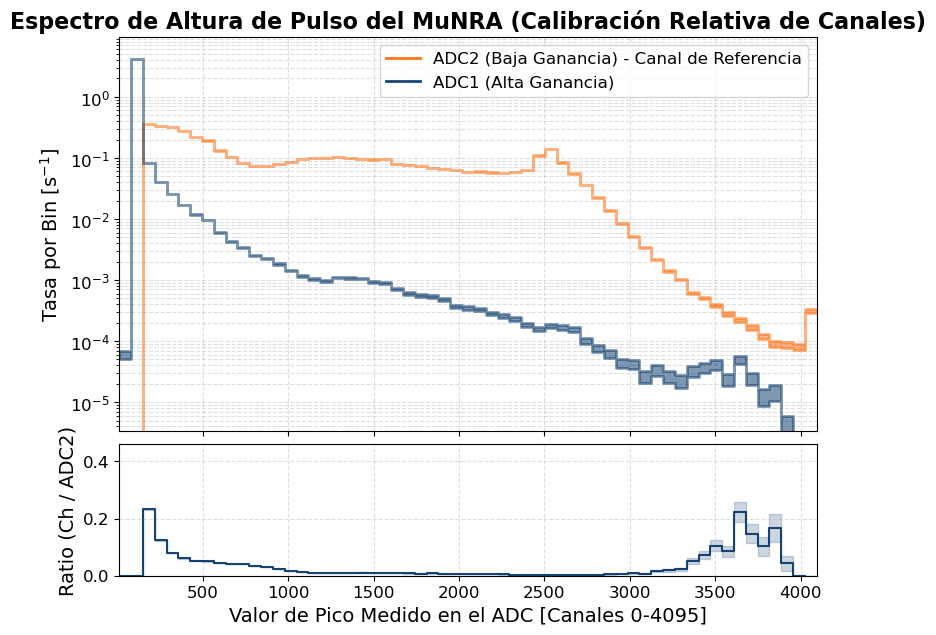

In [22]:

etiqueta_adc2 = f"ADC2 (Baja Ganancia) - Canal de Referencia"
etiqueta_adc1 = f"ADC1 (Alta Ganancia)"


grafico_energia = NPlotMuNRA(
    data=[adc2_low, adc1_high],                 
    weights=[weights, weights],                  
    colors=['#FF6600', '#003366'],               # Naranja para ADC2, Azul para ADC1
    labels=[etiqueta_adc2, etiqueta_adc1],
    xmin=10, xmax=4095,                          
    nbins=60,                                   
    ymin_ratio=0.0, ymax_ratio=None,             # Deja que el código encuentre la altura perfecta
    xscale='linear', yscale='log',               
    xlabel='Valor de Pico Medido en el ADC [Canales 0-4095]',
    title='Espectro de Altura de Pulso del MuNRA (Calibración Relativa de Canales)',
    pdf_name='Espectro_Energia_MuNRA_Corregido.pdf'
)

#nota: si la grafico inferior no se ve bien o no se nota la razon (osea un grafico normal) es porque hay que ajustar max_ratio_detectado = 0.4 


El proposito es la calibración electrónica y diagnóstico donde el eje x va de numero de canales y y el rate. El eje y es la matriz de pesis, esto te permite comparar el detector con otros, ademas la tasa por bin indica la probabilidad real de recibir una partícula con esa energía específica por segundo.

## Como funciona el MUNRA
- Detección: La partícula atraviesa el centellador excitando moléculas que emiten fotones.
- Conversión: El SiPM capta esos fotones y los convierte en un pulso eléctrico proporcional a la intensidad de luz (energía).
-Acondicionamiento: La electrónica amplifica la señal y el Peak Detector mantiene el voltaje máximo del pulso. (aca viene el Threesholds o el trigger)
-Digitalización: El ADC de 12 bits de la Raspberry Pi Pico traduce ese voltaje analógico (0-2.5V) en un número entero entre 0 y 4095. Por eso, el eje X son "canales": representan la magnitud cruda de la energía depositada.

Aca el dibujo de como funciona:

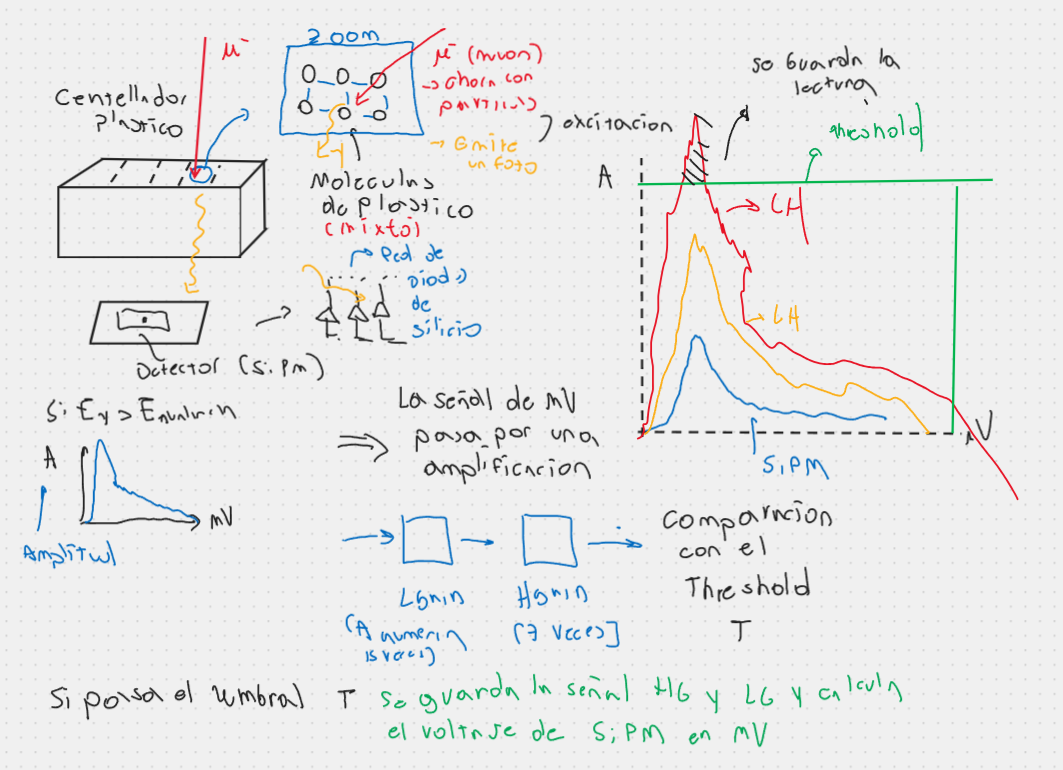


1.  **Señal Cruda (SiPM):** La partícula atraviesa el centellador, el SiPM genera un pulso de corriente muy rápido (Waveform A, típicamente de 10 a 100 mV).
2.  **Primera Amplificación (LGain - Baja Ganancia):** La señal entra a un primer amplificador operacional que la aumenta aproximadamente **15 a 20 veces**. Esta es la señal de "Baja Ganancia" (ADC2), ideal para medir muones muy energéticos o ráfagas que saturarían un canal más sensible.
3.  **Segunda Amplificación (HGain - Alta Ganancia):** Una parte de la señal ya amplificada por el LGain se envía a un segundo amplificador que la aumenta **otras 7 veces más**. Esto genera el canal de "Alta Ganancia" (ADC1), que permite ver con mucha precisión los pulsos pequeños de partículas de baja energía.
4.  **Detección y Disparo:**
    *   La señal de **HGain** es la que normalmente se monitorea contra el **Threshold** porque es la más sensible.
    *   Una vez que el Trigger se activa, el microcontrolador lee **ambos canales** (HGain y LGain) de sus respectivos peak detectors.
5.  **Cálculo Final:** El software toma el valor del ADC1 (HGain) si la señal es pequeña, o el ADC2 (LGain) si la señal es tan grande que el primer canal se saturó, y calcula el valor final de **SiPM [mV]** que ves en tu DataFrame.


A traves de estos canales, mediante na curva de calibración, estos canales se traducen a milivoltios (mV) o Megaelectronvoltios (MeV). Esto es lo fundamental.

#### Nota
**Erratum del RP2040:** Si haces zoom en los bines, podrías notar picos artificiales en los valores 512, 1536, 2560 y 3584. Es un ruido sistemático conocido del microcontrolador Raspberry Pi Pico que no es físico, sino un error de diseño de su ADC. (Ver documentacion). 
Ademas se observa una sutacion de los canales finales (a los 4095), conocido como el overflow bin, que representa eventos tan energéticos que la electrónica no pudo medir.

## Analisis de grafica de valores de amplificacion
El uso de ambos permite que el detector tenga una resolución fina para señales débiles y, al mismo tiempo, la capacidad de registrar "lluvias" de alta energía sin quemar la información en los topes del ADC.
- El ADC1 (Alta Ganancia / HGain): Está diseñado para "hacer zoom" en los pulsos más pequeños. Es vital para observar el espectro de Michel (electrones de decaimiento) y separar el ruido térmico de las partículas de baja energía.
- ADC2 (Baja Ganancia / LGain): Actúa como el canal de referencia para pulsos grandes. u función es evitar que muones muy energéticos o ráfagas de partículas "trunquen" la señal, permitiendo medir eventos que saturarían completamente el canal ADC1.

La parte superior ayuda a ver las se;ales que inducen las particulas al pasar por el centellador (la fisica) y la grafica inferior es validar si la estructura no es por artefacto instrumental. Al usar tasas ($s^{-1}$ ) en lugar de cuentas simples, ambas gráficas se vuelven independientes de la duración de la toma de datos, permitiendo comparar el rendimiento del detector en diferentes días.

La razon (**ratio**) es importante:
- Permite observar visualmente en qué canal la electrónica deja de ser lineal. Si el ratio se desvía drásticamente o se vuelve plano a altos canales, indica que el canal de alta ganancia (ADC1) se ha saturado contra su límite de voltaje
- Sirve para verificar que ambos canales de amplificación estén alineados. Un ratio estable en la zona central asegura que el factor de amplificación entre el HGain y el LGain es constante, lo que permite reconstruir la energía de la partícula con precisión sin importar qué canal se use

#### La zona de estabilidad
entre 700 hasta 3000 hay una razon plana, Esto indica que ambos canales de amplificación (Alta Ganancia - ADC1 y Baja Ganancia - ADC2) están funcionando de manera proporcional y lineal entre sí, lo que ayuda a decir que el factor de amplificacion esta entre 7 veces entre etapas y es constante (esos valores son **fijos** ya que dependen de unicamente como configuramos esas amplificaciones y lo que queriamos), esto nos da una confiabilidad de reconstruir la energia de la particula.

### la zona de saturaciones
A canales bajo como altos esta razon aumenta.
- Paracanles mayor a 3500 se observa la sauracion del canal ADC1, Al ver este cambio en el ratio, debemos inferir que cualquier evento por encima de ese canal debes confiar exclusivamente en el ADC2 (Baja Ganancia), ya que el ADC1 ha perdido su capacidad de medir la altura real del pulso.
- Para canales bajos, los valores son inestables, esto se refiere a el ruido termico del SiPM y de las particulas que rozan el centellador ((corner-clipping muons)). En esta zona, la señal es tan pequeña que las fluctuaciones estadísticas de la electrónica dominan el cálculo del ratio.

lA parte importante es estudiar a se;al del SIiPM

/tmp/ipykernel_9987/2592483221.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Guardando gráfico en: Espectro_SiPM_Filtro_Ruido.pdf


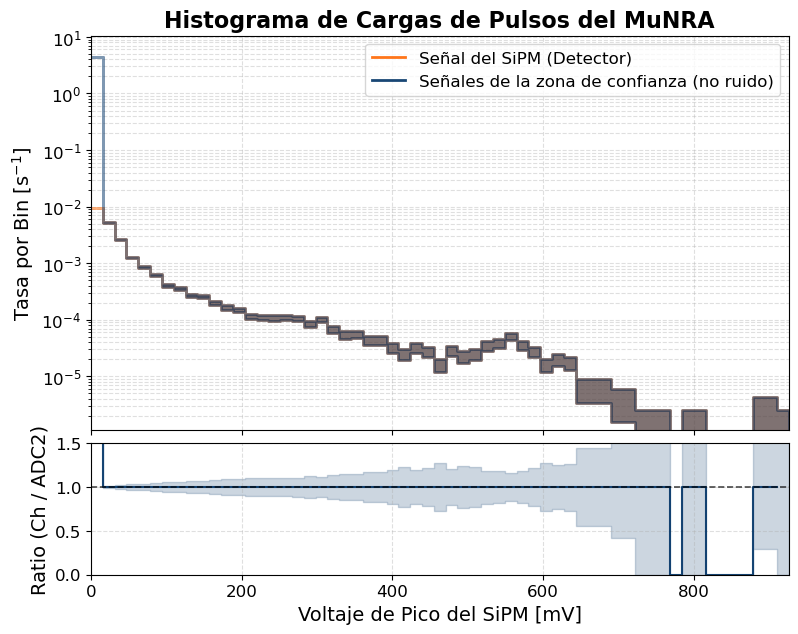

In [23]:

etiqueta_sipm = f"Señal del SiPM (Detector)"
etiqueta_sipm_outnoise = f"Señales de la zona de confianza (no ruido)"

sipm_wn = sipm[sipm > 8.0]
weights_wn = weights[sipm > 8.0]

grafico_energia = NPlotMuNRA(
    data=[sipm_wn,sipm],                       
    weights=[weights_wn,weights], 
    colors=['#FF6600', '#003366'],                   
    labels=[etiqueta_sipm , etiqueta_sipm_outnoise],
    xmin=0, xmax=df_01012026['SiPM_Peak_mV'].values.max(),             
    nbins=60,                                        
    ymin_ratio=0.0, ymax_ratio=1.5,                 
    xscale='linear', yscale='log', 
    xlabel='Voltaje de Pico del SiPM [mV]',     
    title='Histograma de Cargas de Pulsos del MuNRA',     
    pdf_name='Espectro_SiPM_Filtro_Ruido.pdf'     
)


# Analisis de Histograma de Cargas

El analisis de este hisdtograma en terminos de forma y como analisis de amplitud es similar, pero esta parte es la fisica que se produce en el dispositivo.

- las zonas sombreadas o "regiones oscuras" que rodean las líneas del gráfico representan la incertidumbre estadística de las medicionen.  Dado que la llegada de rayos cósmicos son eventos aleatorios y raros, si ``N`` aumenta en un bin, la incertidumbre tambien lo hace. Esto hace que esos errores aumente a altas energias.
- Las bandas indican que el valor real de la tasa tiene una alta probabilidad de encontrarse dentro de ese margen sombreado.

### Descompocision de regiones de datos.
- Región de Ruido y "Corner-clippers" (0 - 50 mV): Es la "montaña" inicial masiva que decae rápidamente. Contiene ruido térmico del SiPM (dark counts) y radiación ambiental (β y γ), ambién aparecen muones que solo rozaron una esquina del plástico (corner-clipping), depositando muy poca energía.
- **El Pico del Muón o "MIP Bump" (~600 mV)**: Esta es la "joroba". Físicamente es el Muón Mínimo Ionizante (MIP), partículas que atravesaron el cm de plástico depositando, en promedio, 2 MeV.
- Cola de Landau-Moyal: Después de la joroba, la tasa de eventos cae lentamente hacia energías más altas. Esta forma sigue la distribución de Landau (aproximada por una curva de Moyal), que describe las fluctuaciones en la pérdida de energía de partículas cargadas en absorbedores delgados.
- Bin de Desbordamiento (Saturación): El repunte vertical al final del eje X representa eventos tan energéticos que saturaron la electrónica de ganancia dual o superaron el límite de lectura del ADC.


## El MIP Bump
El MIP (Minimum Ionizing Particle) Bump o "joroba de ionización mínima" es la estructura más característica en el espectro. Representa a los muones que atraviesan completamente el plástico centellador, a diferencia del ruido o la radiación ambiental que se detiene o deposita energía errática, los muones de rayos cósmicos son muy penetrantes y depositan energía de forma muy predecible.

Su valor de los Muones con esa energia al atravezar estos detectores es de en promedio **2MeV** lo cual es un valor estandar, y la razon que es una constante fundamental de la interacción de la materia con partículas cargadas altamente energéticas (relativistas).

- Poder de Frenado: En materiales ligeros como el agua o el plástico centellador (poliestireno), la tasa de pérdida de energía de un muón alcanza un punto mínimo cuando su velocidad es cercana a la de la luz.
- La Constante: Este mínimo de ionización es de aproximadamente **2.2 MeV** por cada centímetro de material con densidad cercana a $1.0 g/cm^3 $. En el MuNRA las especificaciones son  de 1cm de espesor y densidad de 1.03 (especificaciones de laboratorio), es equivalente.
Ese valor se calcula por la formula de **Bethe (o Bethe-Bloch)**, que calcula la perdida de energia por longitud basado en la carga y velocidad de la partícula , la densidad electrónica del material  y el potencial de excitación medio del material.

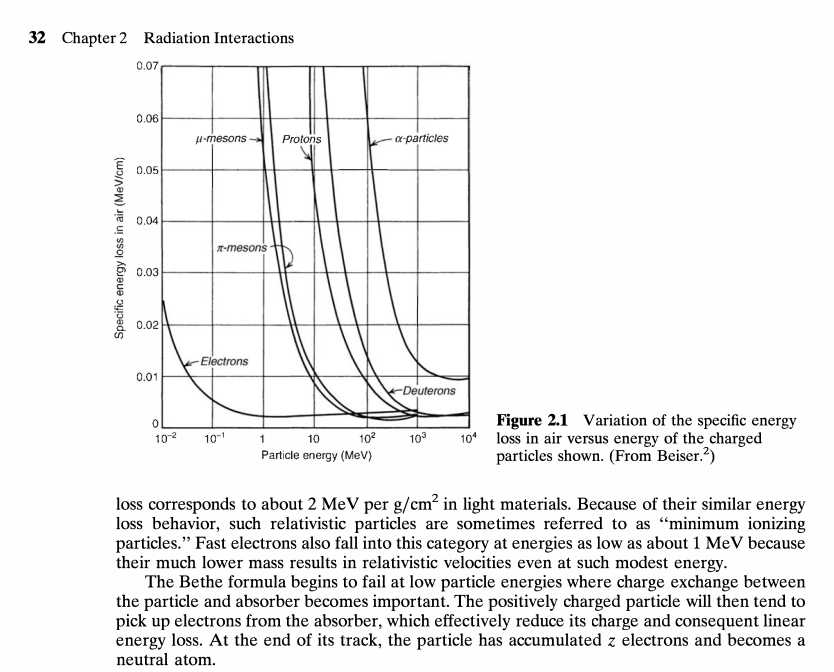


### Funcionamiento de Trigger y conversion a mV
Antes de definir o hacer ekl analisis, recordamos que el Thresholds es de basado en s``elf.SignalThreshold = valor #[0 - 4095 on HGain]`` donde ese valor para el valor de ALTAGANANCIA.

- El escalado interno para obtener una conversion a uan resolucion de 12 bits a 16 bits util para Micropython. ``d.TriggerThreshold = int(d.SignalThreshold * 16)``

- Luego en el bucle de ejecución, el sistema compara el valor crudo del ADC contra ese umbral: ``if (e.ADC_value_2 > d.TriggerThreshold): trigger_Detector(d,e)``.

- Lo que pasa internamente es que El Raspberry Pi Pico genera una señal PWM basada en ese número, luego esa señal pasa por un filtro RC que la convierte en un voltaje DC estable y por ultimo, ese voltaje es el que llega al Comparador (Trigger), el cual decide físicamente si el pulso de la partícula es lo suficientemente alto para ser procesado.

La Conversión a milivoltios (mV), la señal real del SiPM en milivoltios, debemos aplicar las funciones de calibración. Depende sobre que canal se usa de referencia para pasar a mV.

Usando el TRigger en ese momento que era de ``T = 80 ADC``.

#### Caso A: Canal de Alta Ganancia (ADC1 / HGain)
Si el umbral actúa sobre la etapa más sensible para captar partículas de baja energía:
$$\text{Voltaje (mV)} = \text{ADC} \times \left( \frac{15}{4095} \right)$$
*   **Resultado:** $80 \times 0.00366 \approx \mathbf{0.29 \, mV}$. Este umbral sería extremadamente bajo, captando casi todo el ruido térmico del SiPM.

#### Caso B: Canal de Baja Ganancia (ADC2 / LGain)
Si el sistema monitorea el canal de referencia (como sugiere tu bucle `while` en `Main.py` al leer `ADC_value_2`):
$$\text{Voltaje (mV)} = \text{ADC} \times \left( \frac{985}{4095} \right) + 15$$
*   **Resultado:** $80 \times 0.2405 + 15 \approx \mathbf{34.2 \, mV}$.
*   **Análisis:** Este valor es mucho más realista. Un umbral físico de **34.2 mV** está perfectamente posicionado por debajo de tu "joroba" de muones de 600 mV, garantizando que el detector sea 100% eficiente para rayos cósmicos pero sordo al ruido de fondo (que suele estar < 10 mV).

Estabilidad Térmica: Los niveles ADC no son absolutos; si la temperatura cambia drásticamente, la ganancia del SiPM se desplaza. Por ello, el manual recomienda monitorear que el pico de muones no se mueva respecto al umbral y se mantenga fijo.

La funcion de ``get_SiPM_peak_voltage(HGain_adc_value, LGain_adc_value)`` es quien hace eso y calcula por canal, usando los datos crudos de ADC:

- ``HGAIN_SiPM_peak_voltage = HGain_adc_value * (15/4095)`` (Escala de 0 a 15 mV).
- ``LGAIN_SiPM_peak_voltage = LGain_adc_value * (985/4095) + 15 `` (Escala de 15 a 1000 mV)

#### Importante
Luego se usa una funcion sigmoide para decidir que canal es mas confiable con un punto de trancision llamado ``turn_over_value`` de 10 mV, donde si el pulso es menor a 10Mv, decae valor de ADC1 (Alta ganancia) pero si es mayor a 10mV, la funcion se trancsiona para usar el de baja ganacia ADC2.

Para el trigger recordemos que esta basado en el de **baja ganancia**, por ende la comparacion es respecto al canal de **baja ganancia**, osea El bucle de ejecución lee constantemente ``e.ADC_value_2 = d.ADC2.read_u16()`` , el umbral se usa con **ADC1**, el caso es el **CasoB**!

Entonces dado un valor de ``T`` en **ADC** que se usa a mV , lo que se traduce a:

$$\text{T (mV)} = T_{ADC} \times \left( \frac{985}{4095} \right) + 15$$

Entonces para el condicional a mV, munra deja pasar se;ales con la siguiente relacion matematica:

$$ \text{mV}_{signal} > T_{ADC}$$

Que si usamos el thresholds anterior, este corresponde a $ \text{mV}_{signal} > 34.2 mV$




## Analisis y diferencia entre el Cosmic Watch v3 y MunRA
La diferencia de lo observado e el histograma de cargas entre ambos debe a una reconfiguración de la ganancia electrónica y los factores de escala en el software.

Lo que diferencia es la joroba que se relaciona con los muones, si fuera lo mismo de Cosmic, este estaria a **21mV**, pero en el MUNRA se observa a **600mV**, esto se debe a que el MunRA se configuro para que este vea voltajes mucho mas altos de manera electronica.

Aca el MunRA es mejor para ver el ruido, ya que el ADC1 ve ese ruido del SiPM pero requiere que el umbral sea lo suficientemente bajo para no perder muones. Aca tambine la saturacion se da mas alla de los 1000mV. Por eso el MUNRA se usa para detectar los Muones perfectamente.

#### Estiramiento por Ganancia de Hardware (Bias Voltage)
La ganancia real del detector depende directamente del voltaje de bias (polarización inversa) aplicado al SiPM.Si el voltaje de bias supera el punto de ruptura (breakdown voltage), la cascada de electrones en el SiPM lleva más energía, lo que resulta en un aumento lineal de la ganancia y la salida de carga. Esto hace que las respuestas analogicas de las se;ales se estiren antes de llegar al microcontrolador ya que el elevador DC es de 30.0V. 

Esto significa que el software está "estirando" los 4096 canales del ADC para cubrir casi un voltio completo. Al desplazar el pico del muón hacia el centro/final de la escala (600 mV) en lugar de dejarlo al principio (21 mV del Cosmic), estás usando más bines del ADC para representar la misma partícula.

Sabemos que el pico de muones se produce por que la particula deposita una energía casi constante de aproximadamente 2 MeV por cada centímetro de plástico o agua y es constante,sin embargo, el valor en milivoltios (mV)  se mueve por factor instrumental. Hay tres factores:

- Ganancia del SiPM : La salida de carga del SiPM aumenta linealmente con el sobrevoltaje (lo anterior)
- Eficiencia de Acoplamiento Óptico: La calidad del pulido del centellador y cómo está pegado al SiPM determinan cuántos fotones llegan realmente al sensor, menos fotones significan un pulso de menor voltaje para la misma energía de 2 MeV.
- Configuración de la Electrónica (Amplificación):Si el sistema usa una etapa de amplificación dual. Si los amplificadores operacionales tienen una ganancia distinta o si el factor de conversión en el código es diferente, el mismo evento físico se reportará en una escala distinta


## NOTA

Para una buena calibracion debemos ajustar el TRigger optimo que veamos menos ruido, **la joroba no cambia del valor de ADC y de mV**, esto porque es la particula si deposita el mismo valor de energia. Lo que cambia al variar los TRiggers elimino el ruido electronico y las señales espurias (como las de fuentes de poder conmutadas) que suelen amontonarse en las bajas energía.

El trigger permite encontrar un valor estable para la medición de la vida media del muón $\tau_\mu$ independientemente del umbral, una vez que el ruido ha sido suprimido. Pero tambien este trigger debe ser no mayor al voltaje que provoca los muones.

## El ruido
El ruido electrónico es uno de los factores más críticos en la medición de la vida media del muón, ya que distorsiona la distribución temporal de los eventos y, por lo tanto, altera el resultado del ajuste matemático.
La vida media se mide calculando el tiempo transcurrido entre dos pulsos consecutivos. Físicamente, esta distribución debería ser la suma de dos funciones exponenciales: una para el decaimiento del muón (~2.2 μs) y otra para el fondo accidental de rayos cósmicos.

## NOTA: El reto es calibrar el MUNRA para ajustar la vida media del MUON.
